<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_11_5_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T81-558: Applications of Deep Neural Networks
**Module 11: Troubleshooting and Evaluating PyTorch Models**  

* Instructor: [Jeff Heaton](https://sites.washu.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.washu.edu/index.html)
* For more information visit the [class website](https://sites.washu.edu/jeffheaton/t81-558/).

# Module 11 Material

* Part 11.1: Debugging with PyTorch Networks [[Notebook]](t81_558_class_11_1_debugging_pytorch.ipynb)
* Part 11.2: Critical PyTorch Errors [[Notebook]](t81_558_class_11_2_critical_errors.ipynb)
* Part 11.3: Overfitting and Underfitting [[Notebook]](t81_558_class_11_3_overfitting.ipynb)
* Part 11.4: Vanishing and Exploding Gradients [[Notebook]](t81_558_class_11_4_gradients.ipynb)
* **Part 11.5: Error Metrics Beyond Accuracy** [[Notebook]](t81_558_class_11_5_metrics.ipynb)

# Google CoLab Instructions

The following code checks that Google CoLab is running and sets up the correct hardware settings for PyTorch.

In [1]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

# Make use of a GPU or MPS (Apple) if one is available.  (see module 2.5)
import torch
has_mps = torch.backends.mps.is_built()
device = "mps" if has_mps else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Note: not using Google CoLab


Using device: mps


# Part 11.5: Error Metrics Beyond Accuracy

Accuracy, the fraction of predictions a classifier gets right, is the first metric everyone learns and the one most often reported. It is also, on its own, one of the most misleading. Accuracy treats every kind of mistake as equally costly and every class as equally important, and neither assumption holds in most real problems. A fraud detector, a medical screening test, and a spam filter all live or die by the mistakes accuracy hides.

The clearest illustration is **class imbalance**. Suppose one in a hundred transactions is fraudulent. A model that blindly labels every transaction as legitimate achieves 99 percent accuracy while catching exactly zero fraud, the one thing it was built to do. Accuracy rewards this useless model handsomely. To evaluate a model honestly, you need metrics that look at *which* mistakes it makes, not just how many.

This section introduces the metrics that reveal what accuracy conceals. For classification, we build the confusion matrix and derive precision, recall, and the F1 score from it, then examine threshold-independent measures like the ROC curve and its area. For regression, where accuracy does not even apply, we cover the standard error measures and what each one emphasizes. Throughout, we compute these metrics on a real, deliberately imbalanced dataset so their differences are concrete rather than abstract.

## Where Accuracy Fails

We begin by training a classifier on an imbalanced binary problem where only about ten percent of the samples belong to the positive class. This ratio is mild compared to real fraud or disease detection, yet it is already enough to expose accuracy's blind spot. After training, we compare the model's accuracy against the accuracy of a trivial baseline that always predicts the majority class.

In [2]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# Imbalanced binary problem: about 10% positives.
X_np, y_np = make_classification(
    n_samples=4000, n_features=20, n_informative=6,
    weights=[0.9, 0.1], random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_np, y_np, test_size=0.3, random_state=0, stratify=y_np)

X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
X_te_t = torch.tensor(X_te, dtype=torch.float32)

model = nn.Sequential(nn.Linear(20, 32), nn.ReLU(), nn.Linear(32, 2))
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()
for _ in range(300):
    opt.zero_grad()
    loss = loss_fn(model(X_tr_t), y_tr_t)
    loss.backward()
    opt.step()

with torch.no_grad():
    probs = torch.softmax(model(X_te_t), dim=1)[:, 1].numpy()
pred = (probs >= 0.5).astype(int)

positive_rate = y_te.mean()
print(f"Positives in the test set: {positive_rate:.1%}")
print(f"Model accuracy:            {accuracy_score(y_te, pred):.3f}")
print(f"Always-predict-majority:   {1 - positive_rate:.3f}")

Positives in the test set: 10.3%
Model accuracy:            0.929
Always-predict-majority:   0.897


The model's accuracy looks respectable, but so does the accuracy of a baseline that never predicts the positive class at all. When a trivial model that does nothing useful scores nearly as well as your trained network, accuracy has told you almost nothing about whether the model actually works. To see what the model does with the rare positive class, we need to break its predictions down by type of outcome.

## The Confusion Matrix

Every metric that follows is built from the **confusion matrix**, a table that cross-tabulates predictions against truth. For binary classification it has four cells: true negatives and true positives, the correct predictions, and false positives and false negatives, the two distinct kinds of mistake. Separating the two kinds of error is the whole point, because in almost every application they carry different costs. A false negative in cancer screening, a missed diagnosis, is far more serious than a false positive that triggers a follow-up test.

Reading the matrix below, the rows are the true classes and the columns are the predicted classes, so the off-diagonal entries are the errors. The bottom-left cell, positives the model labeled negative, is where an imbalanced classifier tends to fail.

In [3]:
cm = confusion_matrix(y_te, pred)
print("Confusion matrix [rows = true class, cols = predicted class]:")
print(f"                 pred 0   pred 1")
print(f"   true 0 (neg)  {cm[0,0]:6d}   {cm[0,1]:6d}")
print(f"   true 1 (pos)  {cm[1,0]:6d}   {cm[1,1]:6d}")

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue negatives:  {tn}")
print(f"False positives: {fp}   (predicted positive, actually negative)")
print(f"False negatives: {fn}   (predicted negative, actually positive)")
print(f"True positives:  {tp}")

Confusion matrix [rows = true class, cols = predicted class]:
                 pred 0   pred 1
   true 0 (neg)    1043       33
   true 1 (pos)      52       72

True negatives:  1043
False positives: 33   (predicted positive, actually negative)
False negatives: 52   (predicted negative, actually positive)
True positives:  72


The matrix exposes what the accuracy number hid: a substantial share of the genuine positives fall in the false-negative cell, missed by the model, even though overall accuracy is high. Those misses are invisible to accuracy because the many easy true negatives dominate the count. The next step is to turn these four numbers into metrics that summarize the two error types directly.

## Precision, Recall, and F1

Three metrics derived from the confusion matrix summarize classifier performance far more honestly than accuracy for imbalanced problems.

* **Precision** answers: of the examples the model labeled positive, what fraction really were positive? It is `TP / (TP + FP)`, and it falls when the model raises too many false alarms.
* **Recall** (also called sensitivity) answers: of the examples that really were positive, what fraction did the model catch? It is `TP / (TP + FN)`, and it falls when the model misses real positives. Recall is the metric the imbalanced classifier above quietly failed.
* **The F1 score** is the harmonic mean of precision and recall, `2 * (precision * recall) / (precision + recall)`. It is high only when *both* precision and recall are high, making it a single balanced summary when you care about the positive class.

There is a fundamental tension between precision and recall: pushing a model to catch more positives (higher recall) usually means accepting more false alarms (lower precision), and vice versa. Which matters more depends entirely on the application. `scikit-learn`'s `classification_report` presents all three metrics for every class at once, and its per-class breakdown is the single most useful text summary of a classifier.

In [4]:
print(classification_report(y_te, pred, target_names=["negative", "positive"], digits=3))

              precision    recall  f1-score   support

    negative      0.953     0.969     0.961      1076
    positive      0.686     0.581     0.629       124

    accuracy                          0.929      1200
   macro avg      0.819     0.775     0.795      1200
weighted avg      0.925     0.929     0.927      1200



The report lays the imbalance bare. The negative class, with abundant examples, shows high precision and recall. The positive class, the one that matters, shows noticeably lower recall: the model misses a meaningful fraction of the true positives even though its overall accuracy looked fine. The `macro avg` row, which weights both classes equally rather than by their frequency, is far less flattering than accuracy and much closer to the truth about the model's usefulness.

## Thresholds, ROC, and AUC

Every metric so far depends on a decision threshold. The model outputs a probability, and we labeled an example positive when that probability was at least 0.5. But 0.5 is an arbitrary choice. Lowering the threshold catches more positives at the cost of more false alarms; raising it does the reverse. Precision, recall, and accuracy all shift as the threshold moves, which means a single value of any of them describes only one operating point.

The **ROC curve** (Receiver Operating Characteristic) captures the model's behavior across *all* thresholds at once. It plots the true positive rate against the false positive rate as the threshold sweeps from high to low. A model that ranks positives above negatives well hugs the top-left corner; a model no better than random guessing lies along the diagonal. The **area under the curve (AUC)** collapses this into a single threshold-independent number: the probability that the model assigns a higher score to a random positive than to a random negative. An AUC of 1.0 is perfect, 0.5 is random. Because AUC does not depend on the threshold or on class balance, it is one of the most reliable single-number summaries of a classifier's ranking ability.

ROC AUC: 0.914


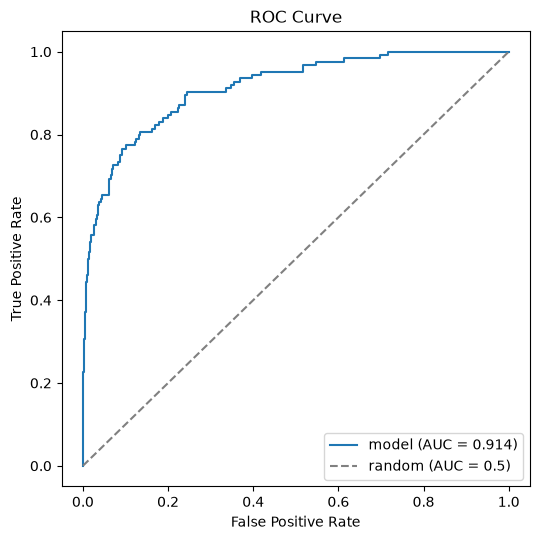

In [5]:
auc = roc_auc_score(y_te, probs)
print(f"ROC AUC: {auc:.3f}")

fpr, tpr, thresholds = roc_curve(y_te, probs)

plt.figure(figsize=(5.5, 5.5))
plt.plot(fpr, tpr, label=f"model (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="random (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

The curve bows toward the top-left corner, well above the diagonal, and the AUC well above 0.5 confirms that the model ranks positives above negatives far better than chance, even though its recall at the default 0.5 threshold was mediocre. This reveals something the earlier metrics did not: the model has learned useful structure, and much of its apparent weakness is a *threshold* problem rather than a *model* problem. By choosing a lower threshold, a point further along the curve, we could trade some precision for the higher recall the application may demand. The ROC curve is the map for making that tradeoff deliberately.

## Regression Metrics

When the target is a continuous number rather than a class, accuracy has no meaning at all, and a different family of metrics takes over. Each summarizes the size of the errors, but they emphasize different things.

* **Mean Absolute Error (MAE)** is the average of the absolute differences between prediction and truth. It is in the same units as the target and treats every error in proportion to its size, which makes it robust to outliers and easy to interpret.
* **Mean Squared Error (MSE)** averages the *squared* errors, so large errors are penalized far more heavily than small ones. This makes MSE sensitive to outliers, which is sometimes exactly what you want and sometimes not.
* **Root Mean Squared Error (RMSE)** is the square root of MSE, which brings the metric back into the target's original units while keeping MSE's heavy penalty on large errors.
* **R-squared** (the coefficient of determination) reports the fraction of the variance in the target that the model explains, on a scale where 1.0 is perfect and 0.0 is no better than always predicting the mean. Unlike the others, it is unitless, which makes it useful for comparing models across different problems.

The example below computes all four on a small synthetic regression to show how they relate.

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rng = np.random.default_rng(0)
y_true = rng.normal(50, 10, size=500)
y_hat = y_true + rng.normal(0, 5, size=500)   # predictions with added error

mae = mean_absolute_error(y_true, y_hat)
mse = mean_squared_error(y_true, y_hat)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_hat)

print(f"MAE:  {mae:6.3f}   average absolute error, in target units")
print(f"MSE:  {mse:6.3f}   penalizes large errors quadratically")
print(f"RMSE: {rmse:6.3f}   square root of MSE, back in target units")
print(f"R2:   {r2:6.3f}   fraction of variance explained (1.0 is perfect)")

MAE:   3.727   average absolute error, in target units
MSE:  22.115   penalizes large errors quadratically
RMSE:  4.703   square root of MSE, back in target units
R2:    0.785   fraction of variance explained (1.0 is perfect)


RMSE comes out larger than MAE on the same predictions, and the gap between them is itself informative: because RMSE squares the errors before averaging, it is pulled upward by the largest mistakes, so a wide RMSE-to-MAE gap signals that a few big errors dominate. The R-squared value reports how much of the target's variance the model captures, independent of the target's scale. Choosing among these metrics is the regression counterpart of choosing between precision and recall: MAE when every error should count in proportion, MSE or RMSE when large errors are especially costly, and R-squared when you need a scale-free measure to compare models.

The unifying theme of this section, and of the whole module, is that a single number rarely tells the truth about a model. Accuracy hides which errors a classifier makes; a low training loss hides overfitting; a stable-looking loss can hide vanishing gradients. Good practice is to look at several complementary measures, choose the ones aligned with what your application actually values, and, as the debugging section urged, make the model's behavior visible rather than trusting any one summary. That habit of thorough, honest evaluation is what separates a model that scores well from one that genuinely works.